# GLiNER2 LoRA Fine-Tuning Tutorial
This notebook shows how to prepare data, train GLiNER2 LoRA adapters, evaluate them, and export predictions for review.

## Table of Contents
1. [Quick navigation](#quick-navigation)
2. [Prerequisites and setup](#prerequisites-and-setup)
3. [GLiNER2 basics](#gliner2-basics)
4. [Model choice: base, multi, or large](#model-choice-base-multi-or-large)
5. [Schema configuration](#schema-configuration)
6. [Data preprocessing](#data-preprocessing)
7. [Single-domain finetuning](#single-domain-finetuning)
8. [Multi-domain finetuning](#multi-domain-finetuning)
9. [Batch processing](#batch-processing)

## Quick Navigation
- If you want to prepare the data first, start at [Data preprocessing](#data-preprocessing).
- If you already have cleaned data, you can jump to [Single-domain finetuning](#single-domain-finetuning).
- If you want specialized adapters for different label groups, go to [Multi-domain finetuning](#multi-domain-finetuning).
- If you want to apply a trained adapter to new texts, go to [Batch processing](#batch-processing).

## Prerequisites and Setup
Before running the notebook, make sure you have:
- A working Python environment
- A GPU if you want training to run efficiently
- Labeled data exported from Label Studio or a similar annotation tool
- The GLiNER2 package installed in the current notebook environment

Practical setup advice:
- Start with a small experiment first so you can verify the pipeline end to end
- Use clear output folder names so you can compare runs later
- Keep the notebook kernel aligned with the environment where you installed dependencies

## GLiNER2 Basics
GLiNER2 is a flexible named entity recognition model that can learn from a schema instead of being limited to one fixed label set.

Why that matters:
- You define which entity types the model should look for
- The same base model can be adapted to different projects
- LoRA adapters let you specialize the model without retraining everything from scratch

When you already know other NER systems, the main difference is that GLiNER2 is more schema-driven and easier to adapt across domains than many fixed-label NER setups.

## Model Choice: Base, Multi, or Large
If you know different NER model families, the main question is not whether GLiNER2 works, but which checkpoint gives you the best balance of speed, accuracy, and training cost.

| Model | Strengths | Trade-offs | Good starting use case |
| --- | --- | --- | --- |
| Base | Fastest to train and easiest to iterate on | Usually the least accurate of the three | First baseline, limited GPU, quick experiments |
| Multi | Strong general-purpose checkpoint for mixed domains | Can be slightly heavier than base | Most default projects, especially when labels are not all from one narrow domain |
| Large | Often best quality when you have enough compute and data | Slower, more memory-intensive, more expensive to fine-tune | Final runs where you want maximum quality and can afford the cost |

Practical guidance:
- Start with the smallest model that can answer your question
- Move to multi if base underfits or if you want a stronger general-purpose checkpoint
- Move to large only if you have evidence that the extra cost is worth it

## Schema Configuration
A schema is the list of entity labels the model is allowed to predict.

For example, your schema may include labels such as person, place, institution, object, or text_title.

Example schema definition:
```json
{
  "entities": {
    "person": "People mentioned in the text",
    "place": "Locations, cities, regions, or buildings",
    "institution": "Institutions, monasteries, churches, or organizations",
    "object": "Physical objects or artifacts",
    "text_title": "Titles, headings, or named text units"
  },
  "relations": {}
}
```

Why this matters:
- A clear schema keeps the model focused on the labels you actually need
- It makes evaluation easier because predictions are compared against a known set of labels
- It makes training more reproducible across runs

Important rules:
- Keep the schema consistent between training and evaluation
- Make label names exact and stable
- If you change the schema, treat that as a new experiment because model behavior and metrics are no longer directly comparable

#
---
🍀 GOOD LUCK ! 🍀
# 
---

# Data preprocessing
This notebook is a practical guide to train and use a GLiNER2 model for named entity recognition.

The workflow is split into four blocks:
1. Data preprocessing
2. Single-domain finetuning
3. Multi-domain finetuning
4. Batch processing

Read the markdown cells before running the code cells. They explain what each choice does, why it matters, and what you give up when you pick one path over another.

### 1. Filter the Label Studio annotations
Label Studio exports often contain multiple versions of the same text, draft annotations, and annotations from multiple annotators.

Why filter first:
- You reduce noise before training
- You avoid mixing conflicting annotations
- You make later evaluation more meaningful

Trade-off:
- If your filtering rule is too strict, you may throw away useful examples
- If it is too loose, you may train on inconsistent labels

In this step, keep the annotations that match your intended training set, for example one trusted annotator or one validated review pass.

In [4]:
import json
import glob

# Paths
input_folder = "./Hagiographics_labeled_data"  # Folder containing all your JSON files
output_path = "./Hagiographics_labeled_data/filtered_data.json"

# Filtering criteria

allowed_annotators = {11}

combined_data = []

# Process each JSON file in the folder
for file_path in glob.glob(f"{input_folder}/*.json"):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Filter by id and annotator
    filtered = [
        item for item in data
        if item.get("annotator") in allowed_annotators
    ]

    combined_data.extend(filtered)

# Save combined filtered data to one file
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(combined_data, f, ensure_ascii=False, indent=2)

print(f"Combined {len(combined_data)} filtered entries into {output_path}.")

Combined 81 filtered entries into ./Hagiographics_labeled_data/filtered_data.json.


### 2. Label Studio to GLiNER2 training data conversion
Here we convert human annotations into the format expected by GLiNER2 training.

Target format per example:
```json
{"text": "text to process", "entities": {"label": ["entity1", "entity2"]}}
```

Important rule: label names in your data must match your schema labels exactly.

In [1]:
import json
from collections import defaultdict


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def convert_to_gliner2_format(annotation_data, schema):
    """
    Converts Label Studio-style annotations to GLiNER2 format.
    Only uses labels defined inside schema["entities"].
    """

    # ✅ Only take actual NER entity types
    entity_types = list(schema["entities"].keys())

    gliner_data = []

    for item in annotation_data:
        text = item["text"]
        annotations = item.get("label", [])

        entities_dict = defaultdict(list)

        # Collect entities
        for ann in annotations:
            entity_text = ann["text"].strip()
            labels = ann.get("labels", [])

            for label in labels:
                # ✅ Only include labels that exist in schema
                if label in entity_types:
                    entities_dict[label].append(entity_text)

        # Deduplicate while preserving order
        for label in entities_dict:
            seen = set()
            deduped = []
            for ent in entities_dict[label]:
                if ent not in seen:
                    deduped.append(ent)
                    seen.add(ent)
            entities_dict[label] = deduped

        # Ensure ALL schema entity types are present (even if empty)
        for entity_type in entity_types:
            if entity_type not in entities_dict:
                entities_dict[entity_type] = []

        formatted_item = {
            "text": text,
            "entities": dict(entities_dict)
            }


        gliner_data.append(formatted_item)

    return gliner_data


def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


if __name__ == "__main__":
    annotation_file = "LS_labeled_data_54.json"
    schema_file = "gliner_schema_hagiographics.json"
    output_file = "gliner2_training_data_54.json"

    annotations = load_json(annotation_file)
    schema = load_json(schema_file)

    gliner_data = convert_to_gliner2_format(annotations, schema)
    save_json(gliner_data, output_file)

    print(f"Converted {len(gliner_data)} examples.")

Converted 54 examples.


### 3. Split data into training, validation, and test sets
Why this matters:
- Training set teaches the model
- Validation set helps tune choices
- Test set gives final unbiased evaluation

Good practice: do not tune hyperparameters based on test results.

In [3]:
!pip install scikit-learn

  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 44.9 MB/s eta 0:00:00a 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl (32.9 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [21]:
import json
import os
from sklearn.model_selection import train_test_split

# ── Config ────────────────────────────────────────────────────────────────────

INPUT_FILE   = "gliner2_training_data_2.json"
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# ── Load, split and save ──────────────────────────────────────────────────────

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)

os.makedirs("./data_2", exist_ok=True)                                             #change dirname if needed

with open("./data_2/train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, indent=2, ensure_ascii=False)

with open("./data_2/test.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, indent=2, ensure_ascii=False)

print(f"Total:  {len(data)} examples")
print(f"Train:  {len(train_data)} examples ({(1 - TEST_SIZE)*100:.0f}%)")
print(f"Test:   {len(test_data)} examples ({TEST_SIZE*100:.0f}%)")
print(f"\n📁 Saved to ./data_2/train.json and ./data_2/test.json")

Total:  81 examples
Train:  64 examples (80%)
Test:   17 examples (20%)

📁 Saved to ./data_2/train.json and ./data_2/test.json


In [61]:
## split the test set in validation and test

import json
import os
from sklearn.model_selection import train_test_split

# ── Config ────────────────────────────────────────────────────────────────────

INPUT_FILE   = "./data_2/test.json"  # change to needed path
TEST_SIZE    = 0.5  # 50% of the test set will become validation, 50% will remain test
RANDOM_STATE = 42

# ── Load, split and save ──────────────────────────────────────────────────────

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

val_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)

os.makedirs("./data_2", exist_ok=True)                                             #change dirname if needed

with open("./data_2/val.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, indent=2, ensure_ascii=False)

with open("./data_2/test.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, indent=2, ensure_ascii=False)

print(f"Total:  {len(data)} examples")
print(f"Validation:  {len(val_data)} examples ({(1 - TEST_SIZE)*100:.0f}%)")
print(f"Test:   {len(test_data)} examples ({TEST_SIZE*100:.0f}%)")
print(f"\n📁 Saved to ./data_2/val.json and ./data_2/test.json")

Total:  17 examples
Validation:  8 examples (50%)
Test:   9 examples (50%)

📁 Saved to ./data_2/val.json and ./data_2/test.json


##

---

# Finetuning GLiNER2 with LoRA
Now that your data is ready, you can train an adapter on top of the base GLiNER2 model.

What is LoRA in simple terms:
- You do not retrain the full model
- You train a small adapter that learns your domain style and labels
- This is faster and lighter than full finetuning

# 1. Single-domain finetuning
In this block, one adapter is trained on all selected labels together. This is usually the easiest starting point and the best baseline to compare against more complex setups.

Pros:
- One training run to manage
- Easier to debug label issues
- Good default when labels share similar text patterns

Cons:
- If some labels behave very differently, one adapter may average out those differences
- Very dominant labels can make weaker labels harder to learn

In [2]:
!pip install gliner2

## Step 1: Prepare training data
Load your training split and convert each sample to InputExample objects used by GLiNER2.

In [ ]:
import json
from gliner2.training.data import InputExample

with open("./data_2/train.json", "r", encoding="utf-8") as f:
    data = json.load(f)

train_data = [
    InputExample(text=item["text"], entities=item["entities"])
    for item in data
]

### [optional: exclude certain entities]
With this code you can exclude a certain entity from your dataset to see what effect it has on the training of the model.

In [ ]:
import json
from gliner2.training.data import InputExample

EXCLUDED_ENTITIES = ["text_title"]

with open("./data_single/train.json", "r", encoding="utf-8") as f:
    data = json.load(f)

train_data = [
    InputExample(
        text=item["text"],
        entities={k: v for k, v in item["entities"].items() if k not in EXCLUDED_ENTITIES}
    )
    for item in data
]

print(train_data[0])  # Print the first example to verify

InputExample(text='[20] Ut superior narrationis series comprehendit, \n\n[Col. 0214B] \n\npostquam sacratissimæ Virginis corpus intemeratum in basilica sanctorum Apostolorum extra muros urbis per annos XXV quieverat, quædam forte religiosarum supra memorati sanctimonialium cœnobii revelatione divina se testata est fuisse commonitam, uti majori ecclesiæ, quæ erat loco subteriori, alia adjacens extrinsecus in honore sanctæ Dei Genitricis Mariæ construeretur basilica; modumque ipsius revelationis hoc ordine referebat; Videbatur, inquiens, mihi quiescenti beata virgo Domini Glodesindis super murum civitatis stans, lapidem eminus, veluti designando loco, manu dejicere, meque verbis insuper compellare. Ibi, inquit, ecclesia fabricetur, & quem in locum lapis casu devenit, in eo beatissimæ semper Virginis Mariæ erigatur altare. Monstrato denique aliam quamdam in partem latere seorsum; Illic, ait, ostium fiat, quo ex ecclesia majori, hoc est monasterio, in eamdem pervius novam sororibus aperiat

## Step 2: Configure LoRA training
Here you define hyperparameters such as epochs, learning rates, batch size, and LoRA rank.

For a first run, keep default values and change only output directory and experiment name.

In [ ]:
from gliner2 import GLiNER2
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig

# LoRA configuration
config = TrainingConfig(
    output_dir="./adapter_single_withoutTT_20ep",  # change this to your desired output directory
    experiment_name="Hagiography",            # change this to your desired experiment name

    # Training parameters
    num_epochs=20,
    batch_size=8,
    gradient_accumulation_steps=2,
    encoder_lr=1e-5,
    task_lr=5e-4,

    # LoRA settings
    use_lora=True,                              # Enable LoRA
    lora_r=4,                                   # Rank (4, 8, 16, 32)
    lora_alpha=8.0,                           # Scaling factor (usually 2*r)
    lora_dropout=0.0,                          # Dropout for LoRA layers
    lora_target_modules=["encoder", "span_rep", "classifier"],           # Apply to all encoder layers (query, key, value, dense)
    save_adapter_only=True,                    # Save only adapter (not full model)

    # Optimization
    eval_strategy="epoch",  # Evaluates and saves at end of each epoch
    eval_steps=500,  # Used when eval_strategy="steps"
    logging_steps=50,
    fp16=True,  # Use mixed precision if GPU available

    early_stopping=False,  # Enable early stopping
    early_stopping_patience=3,  # Stop if no improvement for 3 eval
)

## Step 3: Train the LoRA adapter
This launches training using the configuration above.

Expected result: a saved adapter folder in your output directory.

In [ ]:
eval_data="val.json"  # change to needed path, this is only necessary if you want to use early stopping, otherwise it can be ignored

# Load base model
base_model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")
# Create trainer
trainer = GLiNER2Trainer(model=base_model, config=config)
# Train adapter
trainer.train(train_data=train_data) # for early stopping, add eval_data=val_data

# Adapter automatically saved to the output_dir specified in the cell above 

2026-04-15 10:20:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 10:20:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/config.json "HTTP/1.1 200 OK"
2026-04-15 10:20:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 10:20:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-15 10:20:30 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 10:20:30 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-15 10:20:34 - INFO - gliner2.training.trainer - Using device: cuda
2026-04-15 10:20:34 - INFO - gliner2.training.trainer - Setting up LoRA for parameter-efficient fine-tuning...
2026-04-15 10:20:34 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training
2026-04-15 10:20:34 - INFO - gliner2.training.lora - Applied LoRA to 80 layers
2026-04-15 10:20:34 - INFO - gliner2.training.trainer - LoRA setup complete: 1,548,296 trainable params out of 308,646,941 total (0.50%)


🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 8
Alpha              : 16.0
Scaling (α/r)      : 2.0000
Dropout            : 0.0
Target modules     : encoder, span_rep, classifier
LoRA layers        : 80
----------------------------------------------------------------------
Trainable params   : 1,548,296 / 308,646,941 (0.50%)
Memory savings     : ~99.5% fewer gradients


Validating records: 100%|██████████| 64/64 [00:00<00:00, 10813.98record/s]
2026-04-15 10:20:34 - INFO - gliner2.training.trainer - Optimizer: LoRA params only = 160, LR=0.0005
/home/ghentcdh/heikesupercool/ghentcdh-glinerv2-tutorial/.venv/lib/python3.12/site-packages/gliner2/training/trainer.py:903: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=self.config.fp16)
2026-04-15 10:20:34 - INFO - gliner2.training.trainer - ***** Running Training *****
2026-04-15 10:20:34 - INFO - gliner2.training.trainer -   Num examples = 64
2026-04-15 10:20:34 - INFO - gliner2.training.trainer -   Num epochs = 20
2026-04-15 10:20:34 - INFO - gliner2.training.trainer -   Batch size = 8
2026-04-15 10:20:34 - INFO - gliner2.training.trainer -   Gradient accumulation steps = 2
2026-04-15 10:20:34 - INFO - gliner2.training.trainer -   Effective batch size = 16
2026-04-15 10:20:34 - INFO - gliner2.

{'total_steps': 80,
 'total_epochs': 20,
 'total_time_seconds': 62.82926654815674,
 'samples_per_second': 20.37267137312384,
 'best_metric': inf,
 'train_metrics_history': [{'loss': 249.65060371398926,
   'classification_loss': 0.0,
   'structure_loss': 150.4495086669922,
   'count_loss': 0.0,
   'learning_rate': 0.00020833333333333335,
   'epoch': 12.375,
   'step': 50,
   'samples_seen': 800,
   'throughput': 20.331435332986317}],
 'eval_metrics_history': []}

## Step 4: Evaluate the trained adapter
Compare base model versus adapter on held-out data.

How to interpret metrics:
- Precision: how many predicted entities are correct
- Recall: how many true entities are found
- F1: balance between precision and recall

Always inspect per-entity scores, not only overall score.

In [18]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=83f092c96af4c575f1c46b330bad374f8a423b541b61847632059093ed990be0
  Stored in directory: /home/ghentcdh/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import json
import pandas as pd
from gliner2 import GLiNER2

# ── Config ────────────────────────────────────────────────────────────────────

BASE_MODEL = "fastino/gliner2-multi-v1"
ADAPTER_PATH = "./adapter_single_withoutTT_20ep/final"          #change to needed path
TEST_FILE = "./data_single/test.json"                          #change to needed path

ENTITY_TYPES = ["person", "group", "divine_entity","place", "institution", "object"] # 'text_title' removed

# ── Load test data ────────────────────────────────────────────────────────────

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)


# ── Per-entity metrics helper ─────────────────────────────────────────────────

def compute_per_entity_metrics(pred_entities_dict, true_entities_dict, entity_types):
    metrics = {}
    for label in entity_types:
        true_spans = {s.lower().strip() for s in true_entities_dict.get(label, [])}
        pred_spans = {s.lower().strip() for s in pred_entities_dict.get(label, [])}

        tp = len(pred_spans & true_spans)
        fp = len(pred_spans - true_spans)
        fn = len(true_spans - pred_spans)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) \
            if (precision + recall) > 0 else 0.0

        metrics[label] = {"precision": precision, "recall": recall, "f1": f1,
                          "tp": tp, "fp": fp, "fn": fn}
    return metrics


# ── Evaluate ──────────────────────────────────────────────────────────────────

model = GLiNER2.from_pretrained(BASE_MODEL)

# Accumulate per-entity totals across all samples
all_results = {}

for run_label, load_adapter in [("Base", False), ("Adapter", True)]:
    if load_adapter:
        model.load_adapter(ADAPTER_PATH)
    else:
        model.unload_adapter()

    # Accumulators: tp, fp, fn per entity type
    accum = {e: {"tp": 0, "fp": 0, "fn": 0} for e in ENTITY_TYPES}

    for sample in test_data:
        entity_types = list(sample["entities"].keys())
        pred = model.extract_entities(sample["text"], entity_types)
        per_entity = compute_per_entity_metrics(
            pred["entities"], sample["entities"], ENTITY_TYPES
        )
        for label, m in per_entity.items():
            accum[label]["tp"] += m["tp"]
            accum[label]["fp"] += m["fp"]
            accum[label]["fn"] += m["fn"]

    all_results[run_label] = accum
    print(f"✅ {run_label} evaluated")


# ── Build table ───────────────────────────────────────────────────────────────

def accum_to_metrics(accum_dict):
    rows = []
    total_tp = total_fp = total_fn = 0

    for label in ENTITY_TYPES:
        tp = accum_dict[label]["tp"]
        fp = accum_dict[label]["fp"]
        fn = accum_dict[label]["fn"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) \
            if (precision + recall) > 0 else 0.0
        rows.append({
            "Entity": label,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1": round(f1, 4),
            "TP": tp,
            "FP": fp,
            "FN": fn,
        })

    # Overall row
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Entity": "OVERALL",
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f, 4),
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
    })
    return pd.DataFrame(rows)


df_base = accum_to_metrics(all_results["Base"])
df_adapter = accum_to_metrics(all_results["Adapter"])

# Merge into one table with suffixes
df = df_base.merge(df_adapter, on="Entity", suffixes=(" (Base)", " (Adapter)"))


# ── Style and display ─────────────────────────────────────────────────────────

def highlight_rows(row):
    if row["Entity"] == "OVERALL":
        return ["font-weight: bold; background-color: #f0f0f0"] * len(row)
    return [""] * len(row)


def highlight_better_f1(row):
    styles = [""] * len(row)
    base_f1 = row["F1 (Base)"]
    adapter_f1 = row["F1 (Adapter)"]
    f1_base_idx = row.index.get_loc("F1 (Base)")
    f1_adapter_idx = row.index.get_loc("F1 (Adapter)")
    if adapter_f1 > base_f1:
        styles[f1_adapter_idx] = "color: green; font-weight: bold"
        styles[f1_base_idx] = "color: red"
    elif base_f1 > adapter_f1:
        styles[f1_base_idx] = "color: green; font-weight: bold"
        styles[f1_adapter_idx] = "color: red"
    return styles


fmt = {c: "{:.4f}" for c in df.columns if any(m in c for m in ["Precision", "Recall", "F1"])}

df.style \
    .apply(highlight_rows, axis=1) \
    .apply(highlight_better_f1, axis=1) \
    .format(fmt) \
    .set_caption("GLiNER2 — Base vs Adapter: per-entity evaluation") \
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"), ("font-weight", "bold")]}])

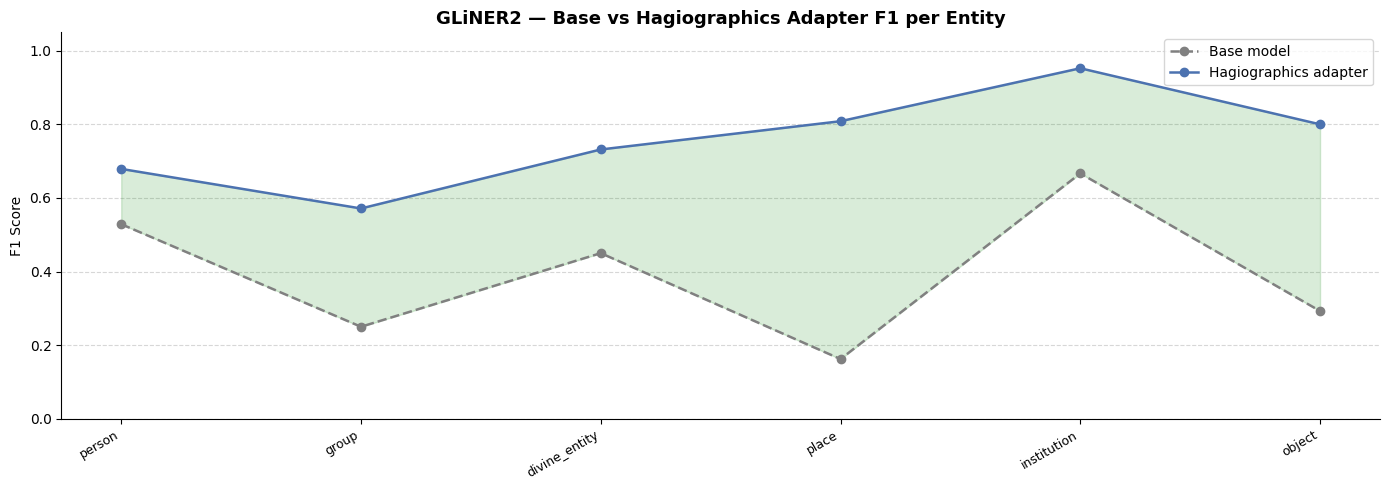

✅ Saved to f1_comparison_single_withoutTT_20ep.png


In [20]:
## make a graph to compare the F1 score

import matplotlib.pyplot as plt
import numpy as np

# ── Pull F1 scores from existing df ──────────────────────────────────────────

df_plot = df[~df["Entity"].str.contains("OVERALL")].copy()

labels = df_plot["Entity"].tolist()
x = np.arange(len(labels))

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, df_plot["F1 (Base)"], color="gray", marker="o",
        linewidth=1.8, markersize=6, linestyle="--", label="Base model")
ax.plot(x, df_plot["F1 (Adapter)"], color="#4C72B0", marker="o",
        linewidth=1.8, markersize=6, linestyle="-", label="Hagiographics adapter")

# Shade green where adapter wins, red where it doesn't
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values >= df_plot["F1 (Base)"].values,
    alpha=0.15, color="green"
)
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values < df_plot["F1 (Base)"].values,
    alpha=0.15, color="red"
)

ax.set_title("GLiNER2 — Base vs Hagiographics Adapter F1 per Entity",           # change title if needed
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("f1_comparison_single_withoutTT_20ep.png", dpi=150, bbox_inches="tight")       # change filename if needed
plt.show()
print("✅ Saved to f1_comparison_single_withoutTT_20ep.png")

## Step 5: Load and test the trained adapter
After training, load the adapter and run extraction on sample text.

Use this step as a quick qualitative check before large-scale batch processing.

In [ ]:
## Load the trained adapter

model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")        # change to needed model!
model.load_adapter("./Hagiography_adaptor_2/final")

# Check if adapter is loaded
if model.has_adapter:
    print("Adapter is loaded")

# Get adapter configuration
config = model.adapter_config
print(f"LoRA rank: {config.lora_r}")

2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-base-v1/283f4af5e598631a5352b8c388b6906853146f07/config.json "HTTP/1.1 200 OK"
2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-base-v1/283f4af5e598631a5352b8c388b6906853146f07/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 10:00:03 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/r

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first
Adapter is loaded
LoRA rank: 8


In [17]:
from gliner_to_labelstudio import (
    load_gliner_schema_config,
    create_gliner_schema_from_config_file,
)
SCHEMA_CONFIG_PATH = "./gliner_schema_hagiographics.json"
schema_config = load_gliner_schema_config(SCHEMA_CONFIG_PATH)

extractor = model

schema = create_gliner_schema_from_config_file(extractor, SCHEMA_CONFIG_PATH)

text = """
[5]  Igitur nocte, qua rapienda erat, meruit angelicam vocem audire se monentem ex nomine: “Recede, inquiens, virgo, recede, et virginitatem, quam Deo consecrasti, inviolatam custodi.” Quæ valde perterrita, obediens jussioni, iter cepit. Cumque Spiritu Sancto duceretur, angelus Domini secundo ei apparuit et viam, quam ceperat, ne desereret imperavit. “Venies, inquit angelus, in villam, quam Meldricem nuncupabis; ibi namque præparavit tibi Deus locum ad perficiendum desiderii tui votum.” Pervenit igitur venerabilis virgo ad locum, quem prædixerat ei angelus; ibique parsimonia miræ abstinenciæ diu vivens, geminæ dilectionis se continebat mandato. Alebatur autem beata Ermelindis solummodo herbis agrestibus, non inferior summis heremi cultoribus: puellares quoque artus teneros duris cruciabat injuriis. Frequentabant quoque eam quique religiosi; sed quanto Dominus famam ejus dilatabat, tanto humilius se agebat. Tandem vero, post multa certamina evocata a Domino, ad cælestem pervenit gloriam; quam, in terris posita, tota devotione quæsivit. Ad cujus exequias non hominum

[Col. 0850B]

turba, sed ymnidici chori Christo cecinerunt gloriam. Et quia Christo fuit dilecta, ab ipsis est officiosissime sepulta. Hæc interea beata virgo quadraginta octo annis latuit aliena a cultu sæculi, solis venerata civibus cæli. Sic denique Christus manifestavit eam huic sæculo, ut, quæ erat jam apud eum glorificata in cælis, etiam apud homines honoraretur in terris.
"""

results = results = extractor.extract(text, schema, threshold=0.1, include_confidence=True, include_spans=True, format_results=False)

print(json.dumps(results, indent=2, ensure_ascii=False))


{
  "entities": [
    {
      "person": [
        {
          "text": "virgo",
          "confidence": 0.9964414238929749,
          "start": 521,
          "end": 526
        },
        {
          "text": "virgo",
          "confidence": 0.9961605072021484,
          "start": 1238,
          "end": 1243
        },
        {
          "text": "virgo",
          "confidence": 0.9960546493530273,
          "start": 111,
          "end": 116
        },
        {
          "text": "virginitatem",
          "confidence": 0.9268738627433777,
          "start": 129,
          "end": 141
        },
        {
          "text": "humilius",
          "confidence": 0.5650051236152649,
          "start": 901,
          "end": 909
        },
        {
          "text": "Meldricem",
          "confidence": 0.5133058428764343,
          "start": 395,
          "end": 404
        }
      ],
      "group": [
        {
          "text": "homines",
          "confidence": 0.9259665608406067,
          "s

#
---

# 2. Multi-domain finetuning
In this block, you train separate adapters for different label groups (domains).

This is useful when labels behave differently and benefit from specialization.

Pros:
- Each adapter can focus on a narrower label family
- Often easier to tune if one group is much harder than the others

Cons:
- More setup and more model files to keep track of
- You need to decide how to group labels, and that decision is not always obvious

## Step 0: Prepare domain-specific datasets
You split one dataset into multiple domain views, for example:
1. people: person, group, divine_entity
2. places: institution, place
3. objects: object
4. texts: text_title

Each domain will be used to train its own adapter.

In [75]:
import json
from pathlib import Path
from typing import List, Dict, Any


def filter_dataset_by_labels(
    data: List[Dict[str, Any]],
    allowed_labels: List[str],
    drop_empty: bool = True,
    keep_all_keys: bool = True
) -> List[Dict[str, Any]]:
    if isinstance(allowed_labels, str):
        allowed_labels = [allowed_labels]

    # Keep order and remove duplicates/spaces from user input.
    allowed_labels = [label.strip() for label in allowed_labels if str(label).strip()]
    allowed_labels = list(dict.fromkeys(allowed_labels))

    if not allowed_labels:
        raise ValueError("allowed_labels must contain at least one label.")

    filtered_data = []

    for sample in data:
        text = sample["text"]
        entities = sample.get("entities", {})

        if keep_all_keys:
            new_entities = {
                label: entities.get(label, [])
                for label in allowed_labels
            }
        else:
            new_entities = {
                label: entities[label]
                for label in allowed_labels
                if label in entities and len(entities[label]) > 0
            }

        has_entities = any(len(v) > 0 for v in new_entities.values())

        if not drop_empty or has_entities:
            filtered_data.append({
                "text": text,
                "entities": new_entities
            })

    return filtered_data


def save_filtered_dataset(
    input_path: str,
    output_path: str,
    allowed_labels: List[str],
    drop_empty: bool = True,
    keep_all_keys: bool = False
):
    """
    Loads dataset, filters it, and saves to a new JSON file.
    """

    # Load dataset
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Filter dataset
    filtered_data = filter_dataset_by_labels(
        data,
        allowed_labels=allowed_labels,
        drop_empty=drop_empty,
        keep_all_keys=keep_all_keys
    )

    # Save new dataset
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(filtered_data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(filtered_data)} samples to {output_path}")


In [76]:
# define your domains and their labels
DOMAIN_LABELS = {
    "people": ["person", "group", "divine_entity"],
    "places": ["place", "institution"],
    "objects": ["object"],
    "texts": ["text_title"]
}

# Create output directory
Path("./data_multi").mkdir(parents=True, exist_ok=True)

# Filter and save for each domain and each split
for split in ["train", "test"]:
    for domain, labels in DOMAIN_LABELS.items():
        save_filtered_dataset(
            input_path=f"./data_2/{split}.json",                # change to needed path
            output_path=f"./data_multi/{split}_{domain}.json",  # change to needed path
            allowed_labels=labels,
            drop_empty=True,
            keep_all_keys=True,
        )
print("Filtering completed.")

Saved 64 samples to ./data_multi/train_people.json
Saved 55 samples to ./data_multi/train_places.json
Saved 46 samples to ./data_multi/train_objects.json
Saved 6 samples to ./data_multi/train_texts.json
Saved 9 samples to ./data_multi/test_people.json
Saved 8 samples to ./data_multi/test_places.json
Saved 7 samples to ./data_multi/test_objects.json
Saved 2 samples to ./data_multi/test_texts.json
Filtering completed.


## Step 1: Load domain-specific training data
For each domain, load the filtered JSON and convert it to InputExample objects.

In [27]:
import json
from gliner2.training.data import InputExample

# Map domains to their filtered JSON files
DOMAIN_FILES = {
    "people": "./data_multi/train_people.json",          # change to needed path
    "places": "./data_multi/train_places.json",          # change to needed path
    "objects": "./data_multi/train_objects.json",        # change to needed path
    "texts": "./data_multi/train_texts.json",            # change to needed path
}


def load_domain_examples(domain_name: str):
    """
    Loads a filtered training dataset for a given domain
    and returns a list of InputExample objects.
    """
    file_path = DOMAIN_FILES.get(domain_name)
    if not file_path:
        raise ValueError(f"No file configured for domain '{domain_name}'.")

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    examples = [
        InputExample(text=item["text"], entities=item["entities"])
        for item in data
    ]

    return examples

# define the domain data
## load the 'people' domain
people_examples = load_domain_examples("people")

## load the 'places' domain
places_examples = load_domain_examples("places")

## load the 'objects' domain
objects_examples = load_domain_examples("objects")

## load the 'texts' domain
texts_examples = load_domain_examples("texts")


## Step 2: Configure multi-domain LoRA training
Define one reusable training function so each domain can be trained with the same logic and settings.

In [25]:
import gc
import torch

def train_domain_adapter(
    base_model_name: str,
    examples: list,
    domain_name: str,
    output_dir: str = "./adapters_multi_r8"
):
    """Train a LoRA adapter for a specific domain."""
    adapter_path = f"{output_dir}/{domain_name}_adapter"

    config = TrainingConfig(
        output_dir=adapter_path,
        experiment_name=f"{domain_name}_domain",
        num_epochs=10,
        batch_size=8,                      # reduced from 8
        gradient_accumulation_steps=2,     # increased to compensate (effective batch = 16)
        encoder_lr=1e-5,
        task_lr=5e-4,

        use_lora=True,
        lora_r=8,                         # reduced from 8
        lora_alpha=16.0,
        lora_dropout=0.0,
        lora_target_modules=["encoder"],
        save_adapter_only=True,
        
        eval_strategy="epoch",
        eval_steps=500,
        logging_steps=50,
        fp16=True,
    )

    print(f"\n{'='*60}")
    print(f"Training {domain_name.upper()} adapter")
    print(f"{'='*60}")

    model = GLiNER2.from_pretrained(base_model_name)
    trainer = GLiNER2Trainer(model=model, config=config)
    results = trainer.train(train_data=examples)

    final_path = f"{adapter_path}/final"
    print(f"\n✅ {domain_name.capitalize()} adapter trained!")
    print(f"📁 Saved to: {final_path}/")
    print(f"⏱️  Training time: {results['total_time_seconds']:.2f}s")

    # ✅ Explicitly free GPU memory before the next domain
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

    return final_path

## Step 3: Train all domain adapters
This runs training sequentially for each domain and saves each adapter in its own folder.

In [28]:
from gliner2 import GLiNER2
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig

if __name__ == "__main__":
    BASE_MODEL = "fastino/gliner2-multi-v1"

    DOMAINS = ["people", "places", "objects", "texts"]

    adapter_paths = {}
    for domain in DOMAINS:
        examples = load_domain_examples(domain)   # load only when needed
        adapter_paths[domain] = train_domain_adapter(BASE_MODEL, examples, domain)
        del examples                               # free RAM too
        gc.collect()

    print("\n" + "="*60)
    print("🎉 All adapters trained successfully!")
    print("="*60)
    for domain, path in adapter_paths.items():
        print(f"{domain.capitalize()} adapter: {path}")

2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/config.json "HTTP/1.1 200 OK"



Training PEOPLE adapter


2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/config.json "HTTP/1.1 200 OK"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:02:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-15 11:02:49 - INFO - gliner2.training.trainer - Using device: cuda
2026-04-15 11:02:49 - INFO - gliner2.training.trainer - Setting up LoRA for parameter-efficient fine-tuning...
2026-04-15 11:02:49 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training
2026-04-15 11:02:49 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:02:49 - INFO - gliner2.training.trainer - LoRA setup complete: 1,327,104 trainable params out of 308,425,749 total (0.43%)


...

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-15 11:04:13 - INFO - gliner2.training.trainer - Using device: cuda
2026-04-15 11:04:13 - INFO - gliner2.training.trainer - Setting up LoRA for parameter-efficient fine-tuning...
2026-04-15 11:04:13 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training
2026-04-15 11:04:13 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:04:13 - INFO - gliner2.training.trainer - LoRA setup complete: 1,327,104 trainable params out of 308,425,749 total (0.43%)


🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 8
Alpha              : 16.0
Scaling (α/r)      : 2.0000
Dropout            : 0.0
Target modules     : encoder
LoRA layers        : 72
----------------------------------------------------------------------
Trainable params   : 1,327,104 / 308,425,749 (0.43%)
Memory savings     : ~99.6% fewer gradients


Validating records: 100%|██████████| 6/6 [00:00<00:00, 29572.06record/s]
2026-04-15 11:04:13 - WARNING - gliner2.training.trainer - Training dataset size (6) is smaller than batch_size (8). Adjusting batch_size to 6.
2026-04-15 11:04:13 - WARNING - gliner2.training.trainer - gradient_accumulation_steps (2) is larger than batches per epoch (1). Setting to 1 update step per epoch.
2026-04-15 11:04:13 - INFO - gliner2.training.trainer - Optimizer: LoRA params only = 144, LR=0.0005
2026-04-15 11:04:13 - INFO - gliner2.training.trainer - ***** Running Training *****
2026-04-15 11:04:13 - INFO - gliner2.training.trainer -   Num examples = 6
2026-04-15 11:04:13 - INFO - gliner2.training.trainer -   Num epochs = 10
2026-04-15 11:04:13 - INFO - gliner2.training.trainer -   Batch size = 8
2026-04-15 11:04:13 - INFO - gliner2.training.trainer -   Gradient accumulation steps = 2
2026-04-15 11:04:13 - INFO - gliner2.training.trainer -   Effective batch size = 16
2026-04-15 11:04:13 - INFO - gliner2


✅ Texts adapter trained!
📁 Saved to: ./adapters_multi_r8/texts_adapter/final/
⏱️  Training time: 3.43s

🎉 All adapters trained successfully!
People adapter: ./adapters_multi_r8/people_adapter/final
Places adapter: ./adapters_multi_r8/places_adapter/final
Objects adapter: ./adapters_multi_r8/objects_adapter/final
Texts adapter: ./adapters_multi_r8/texts_adapter/final


## Step 4: Evaluate the multi-domain setup
Compare base model and domain adapters with per-entity metrics and visualizations.

This tells you whether specialization improved extraction quality.

In [39]:
!pip install matplotlib

In [29]:
def compute_metrics(pred_entities_dict, true_entities_dict):
    # Flatten both dicts to sets of (span, label) tuples
    true_set = {
        (span.lower().strip(), label)
        for label, spans in true_entities_dict.items()
        for span in spans
    }
    pred_set = {
        (span.lower().strip(), label)
        for label, spans in pred_entities_dict.items()
        for span in spans
    }

    tp = len(pred_set & true_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {"precision": precision, "recall": recall}


def evaluate_adapter(model, adapter_path, test_data):
    model.load_adapter(adapter_path)

    results = {
        "total":         0,
        "precision_sum": 0,
        "recall_sum":    0,
    }

    for sample in test_data:
        entity_types = list(sample["entities"].keys())
        pred = model.extract_entities(sample["text"], entity_types)

        metrics = compute_metrics(pred["entities"], sample["entities"])
        results["total"]         += 1
        results["precision_sum"] += metrics["precision"]
        results["recall_sum"]    += metrics["recall"]

    avg_precision = results["precision_sum"] / results["total"]
    avg_recall    = results["recall_sum"]    / results["total"]
    f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) \
         if (avg_precision + avg_recall) > 0 else 0.0

    return {
        "precision": avg_precision,
        "recall":    avg_recall,
        "f1":        f1,
        "samples":   results["total"],
    }

In [30]:
import json
import pandas as pd
from gliner2 import GLiNER2

# ── Config ────────────────────────────────────────────────────────────────────

BASE_MODEL = "fastino/gliner2-multi-v1"
OUTPUT_DIR = "./adapters_multi_r8"          # change to needed path

DOMAIN_ENTITIES = {
    "people": ["person", "group", "divine_entity"],
    "places": ["place", "institution"],
    "objects": ["object"],
    "texts": ["text_title"],
}

TEST_FILES = {
    "people": "./data_multi/test_people.json",          # change to needed path
    "places": "./data_multi/test_places.json",          # change to needed path
    "objects": "./data_multi/test_objects.json",        # change to needed path
    "texts": "./data_multi/test_texts.json",            # change to needed path
}

# ── Helpers ───────────────────────────────────────────────────────────────────

def load_test_examples(domain_name):
    with open(TEST_FILES[domain_name], "r", encoding="utf-8") as f:
        return json.load(f)

def compute_per_entity_metrics(pred_dict, true_dict, entity_types):
    metrics = {}
    for label in entity_types:
        true_spans = {s.lower().strip() for s in true_dict.get(label, [])}
        pred_spans = {s.lower().strip() for s in pred_dict.get(label, [])}
        tp = len(pred_spans & true_spans)
        fp = len(pred_spans - true_spans)
        fn = len(true_spans - pred_spans)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        metrics[label] = {"tp": tp, "fp": fp, "fn": fn,
                          "precision": precision, "recall": recall, "f1": f1}
    return metrics

def accum_to_df(accum_dict, entity_types, domain):
    rows = []
    total_tp = total_fp = total_fn = 0

    for label in entity_types:
        tp = accum_dict[label]["tp"]
        fp = accum_dict[label]["fp"]
        fn = accum_dict[label]["fn"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        rows.append({
            "Domain":    domain.capitalize(),
            "Entity":    label,
            "Precision": round(precision, 4),
            "Recall":    round(recall,    4),
            "F1":        round(f1,        4),
            "TP": tp, "FP": fp, "FN": fn,
        })

    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Domain":    domain.capitalize(),
        "Entity":    f"{domain.upper()} OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
    })
    return rows

# ── Evaluate ──────────────────────────────────────────────────────────────────

model = GLiNER2.from_pretrained(BASE_MODEL)

all_rows_base    = []
all_rows_adapter = []

global_accum = {
    "base":    {"tp": 0, "fp": 0, "fn": 0},
    "adapter": {"tp": 0, "fp": 0, "fn": 0},
}

for domain, entity_types in DOMAIN_ENTITIES.items():
    adapter_path = f"{OUTPUT_DIR}/{domain}_adapter/final"
    test_data    = load_test_examples(domain)

    accum_base    = {e: {"tp": 0, "fp": 0, "fn": 0} for e in entity_types}
    accum_adapter = {e: {"tp": 0, "fp": 0, "fn": 0} for e in entity_types}

    for run_label, accum, load_adapter in [
        ("Base",    accum_base,    False),
        ("Adapter", accum_adapter, True),
    ]:
        if load_adapter:
            model.load_adapter(adapter_path)
        else:
            model.unload_adapter()

        for sample in test_data:
            pred = model.extract_entities(sample["text"], entity_types)
            per_entity = compute_per_entity_metrics(
                pred["entities"], sample["entities"], entity_types
            )
            for label, m in per_entity.items():
                accum[label]["tp"] += m["tp"]
                accum[label]["fp"] += m["fp"]
                accum[label]["fn"] += m["fn"]

    # ✅ Fixed: no break, accumulate all labels correctly
    for label in entity_types:
        for key in ["tp", "fp", "fn"]:
            global_accum["base"][key]    += accum_base[label][key]
            global_accum["adapter"][key] += accum_adapter[label][key]

    all_rows_base    += accum_to_df(accum_base,    entity_types, domain)
    all_rows_adapter += accum_to_df(accum_adapter, entity_types, domain)
    print(f"✅ {domain} evaluated ({len(test_data)} samples)")

# ── Add global OVERALL row ────────────────────────────────────────────────────

for run_label, accum, rows in [
    ("base",    global_accum["base"],    all_rows_base),
    ("adapter", global_accum["adapter"], all_rows_adapter),
]:
    tp, fp, fn = accum["tp"], accum["fp"], accum["fn"]
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Domain":    "ALL",
        "Entity":    "OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
        "TP": tp, "FP": fp, "FN": fn,
    })

# ── Merge and display ─────────────────────────────────────────────────────────

df_base    = pd.DataFrame(all_rows_base)
df_adapter = pd.DataFrame(all_rows_adapter)

df = df_base.merge(df_adapter, on=["Domain", "Entity"],
                   suffixes=(" (Base)", " (Adapter)"))

def highlight_rows(row):
    if row["Entity"] == "OVERALL":
        return ["font-weight: bold; background-color: #d0d0d0"] * len(row)
    if "OVERALL" in str(row["Entity"]):
        return ["font-weight: bold; background-color: #f0f0f0"] * len(row)
    return [""] * len(row)

def highlight_better_f1(row):
    styles = [""] * len(row)
    cols = list(row.index)
    if "F1 (Base)" in cols and "F1 (Adapter)" in cols:
        bi = cols.index("F1 (Base)")
        ai = cols.index("F1 (Adapter)")
        if row["F1 (Adapter)"] > row["F1 (Base)"]:
            styles[ai] = "color: green; font-weight: bold"
            styles[bi] = "color: red"
        elif row["F1 (Base)"] > row["F1 (Adapter)"]:
            styles[bi] = "color: green; font-weight: bold"
            styles[ai] = "color: red"
    return styles

fmt = {c: "{:.4f}" for c in df.columns
       if any(m in c for m in ["Precision", "Recall", "F1"])}

df.style \
  .apply(highlight_rows,      axis=1) \
  .apply(highlight_better_f1, axis=1) \
  .format(fmt) \
  .set_caption("GLiNER2 — Base vs Domain Adapters: per-entity evaluation") \
  .set_table_styles([{"selector": "caption",
                      "props": [("font-size", "14px"), ("font-weight", "bold")]}])

2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/config.json "HTTP/1.1 200 OK"
2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 11:05:08 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-15 11:05:17 - INFO - gliner2.training.lora - Loaded 144 LoRA tensors from adapters_multi_r8/people_adapter/final/adapter_weights.safetensors
2026-04-15 11:05:17 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:05:17 - INFO - gliner2.training.lora - Loaded LoRA adapter from adapters_multi_r8/people_adapter/final
2026-04-15 11:05:22 - INFO - gliner2.training.lora - Unloaded 72 LoRA layers


✅ people evaluated (9 samples)


2026-04-15 11:05:26 - INFO - gliner2.training.lora - Loaded 144 LoRA tensors from adapters_multi_r8/places_adapter/final/adapter_weights.safetensors
2026-04-15 11:05:26 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:05:26 - INFO - gliner2.training.lora - Loaded LoRA adapter from adapters_multi_r8/places_adapter/final
2026-04-15 11:05:31 - INFO - gliner2.training.lora - Unloaded 72 LoRA layers


...

2026-04-15 11:05:34 - INFO - gliner2.training.lora - Loaded 144 LoRA tensors from adapters_multi_r8/objects_adapter/final/adapter_weights.safetensors
2026-04-15 11:05:34 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:05:34 - INFO - gliner2.training.lora - Loaded LoRA adapter from adapters_multi_r8/objects_adapter/final
2026-04-15 11:05:38 - INFO - gliner2.training.lora - Unloaded 72 LoRA layers


✅ objects evaluated (7 samples)


2026-04-15 11:05:39 - INFO - gliner2.training.lora - Loaded 144 LoRA tensors from adapters_multi_r8/texts_adapter/final/adapter_weights.safetensors
2026-04-15 11:05:39 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-15 11:05:39 - INFO - gliner2.training.lora - Loaded LoRA adapter from adapters_multi_r8/texts_adapter/final


✅ texts evaluated (2 samples)


,Domain,Entity,Precision (Base),Recall (Base),F1 (Base),TP (Base),FP (Base),FN (Base),Precision (Adapter),Recall (Adapter),F1 (Adapter),TP (Adapter),FP (Adapter),FN (Adapter)
0,People,person,0.7692,0.3448,0.4762,20,6,38,0.7317,0.5172,0.6061,30,11,28
1,People,group,0.3750,0.2500,0.3000,3,5,9,0.6667,0.5000,0.5714,6,3,6
2,People,divine_entity,0.4737,0.3913,0.4286,9,10,14,0.9000,0.3913,0.5455,9,1,14
3,People,PEOPLE OVERALL,0.6038,0.3441,0.4384,32,21,61,0.7500,0.4839,0.5882,45,15,48
4,Places,place,0.3000,0.1200,0.1714,3,7,22,0.9444,0.6800,0.7907,17,1,8
5,Places,institution,0.8750,0.6364,0.7368,7,1,4,0.6923,0.8182,0.7500,9,4,2
6,Places,PLACES OVERALL,0.5556,0.2778,0.3704,10,8,26,0.8387,0.7222,0.7761,26,5,10
7,Objects,object,0.0500,0.0714,0.0588,1,19,13,0.3600,0.6429,0.4615,9,16,5
8,Objects,OBJECTS OVERALL,0.0500,0.0714,0.0588,1,19,13,0.3600,0.6429,0.4615,9,16,5
9,Texts,text_title,0.5000,0.3333,0.4000,1,1,2,0.5000,0.3333,0.4000,1,1,2


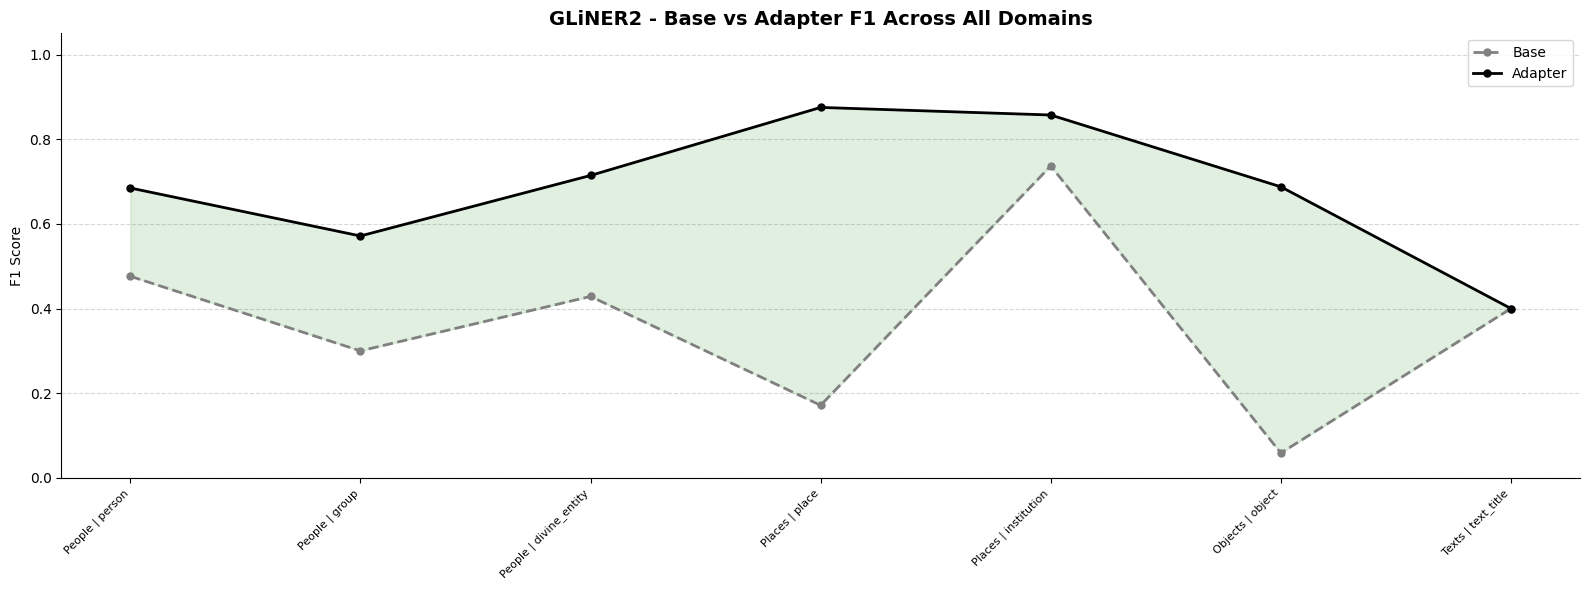

Saved to f1_comparison_multidomain_30_epochs.png


In [87]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ── Pull F1 scores from the existing df ──────────────────────────────────────
# Keep only per-entity rows (remove OVERALL summaries)
df_plot = df[~df["Entity"].str.contains("OVERALL")].copy()

# Build combined x-axis labels so all domains are shown in one chart
df_plot["Domain_Entity"] = df_plot["Domain"].astype(str) + " | " + df_plot["Entity"].astype(str)
labels = df_plot["Domain_Entity"].tolist()
x = np.arange(len(labels))

# ── Plot: single chart comparing Base vs Adapter ──────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    x,
    df_plot["F1 (Base)"].values,
    color="gray",
    marker="o",
    linewidth=2,
    markersize=5,
    linestyle="--",
    label="Base"
    )
ax.plot(
    x,
    df_plot["F1 (Adapter)"].values,
    color="black",
    marker="o",
    linewidth=2,
    markersize=5,
    linestyle="-",
    label="Adapter"
    )

# Optional shading to highlight where Adapter improves or drops
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values >= df_plot["F1 (Base)"].values,
    alpha=0.12,
    color="green",
    label="_nolegend_"
    )
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values < df_plot["F1 (Base)"].values,
    alpha=0.12,
    color="red",
    label="_nolegend_"
    )

ax.set_title("GLiNER2 - Base vs Adapter F1 Across All Domains", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("f1_comparison_multidomain_30_epochs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to f1_comparison_multidomain_30_epochs.png")

#
---

# 3. Batch processing
Now you apply the trained adapter(s) to many texts and export results for review.

This is the practical inference stage after training and evaluation.

Why batch processing is useful:
- It lets you test the model on realistic data volume
- It helps you find recurring mistakes across many documents
- It gives you outputs that can be checked in Label Studio or another annotation tool

Trade-off:
- Batch output is only useful if the schema and model version are clearly tracked

### Step 0: Preprocessing
Prepare your input files so each text unit is clean and ready for extraction.

In [ ]:
# in this codeblock I split the original text file into separate files for each section, based on the pattern [number]. 
# The preamble (if any) is saved as a separate file with an empty brackets in the name. All files are saved to a specified output directory. 
# You can change the input filename and output directory as needed.

import re
import os

def split_text_file(input_file):
    with open(input_file, 'r', encoding='utf-8') as f:
        content = f.read()

    split_pattern = re.compile(r'(?=\[\d+\])')
    parts = split_pattern.split(content)

    base_name = os.path.splitext(os.path.basename(input_file))[0]

    # Create output folder next to your notebook
    output_dir = "test_texts/split_texts"
    os.makedirs(output_dir, exist_ok=True)  # Creates the folder if it doesn't exist

    saved_files = []

    # Handle preamble
    preamble = parts[0].strip()
    if preamble:
        preamble_file = os.path.join(output_dir, f"{base_name}_[].txt")
        with open(preamble_file, 'w', encoding='utf-8') as f:
            f.write(preamble)
        saved_files.append(preamble_file)

    # Handle each numbered section
    for part in parts[1:]:
        match = re.match(r'\[(\d+)\]', part)
        if match:
            number = match.group(1)
            output_file = os.path.join(output_dir, f"{base_name}_[{number}].txt")
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write(part.strip())
            saved_files.append(output_file)

    return saved_files

# --- Run it ---
input_file = "test_texts/BHL7120-7125 - clean.txt"  # 👈 Change this to your filename
files = split_text_file(input_file)

print(f"Created {len(files)} file(s):")
for f in files:
    print(f"  {f}")

### Step 1: Load a batch of texts
Read all text files from a folder into memory and keep filenames for traceability.

In [1]:
import glob
import os
import re

# Define the folder containing your .txt files
input_folder = 'test_texts/split_texts/BHL2605-clean'  # change this to your folder path

# Custom sort key: [preambule] → -1, [number] → that number
def sort_key(filepath):
    filename = os.path.basename(filepath)
    if '[preambule]' in filename.lower():
        return -1
    match = re.search(r'\[(\d+)\]', filename)
    return int(match.group(1)) if match else float('inf')

# Find and sort all .txt files
txt_files = sorted(glob.glob(os.path.join(input_folder, '*.txt')), key=sort_key)

# Load all texts and keep track of filenames
texts_batch = []
filenames = []

for txt_file in txt_files:
    with open(txt_file, 'r', encoding='utf-8') as f:
        text = f.read()
        texts_batch.append(text)
        filenames.append(os.path.basename(txt_file))

print(f"✓ Loaded {len(texts_batch)} text files from {input_folder}")
for i, filename in enumerate(filenames):
    print(f"  {i+1}. {filename} ({len(texts_batch[i])} characters)")

✓ Loaded 7 text files from test_texts/split_texts/BHL2605-clean
  1. BHL2605 - clean_[1].txt (1015 characters)
  2. BHL2605 - clean_[2].txt (660 characters)
  3. BHL2605 - clean_[3].txt (970 characters)
  4. BHL2605 - clean_[4].txt (1548 characters)
  5. BHL2605 - clean_[5].txt (1465 characters)
  6. BHL2605 - clean_[6].txt (1050 characters)
  7. BHL2605 - clean_[7].txt (1082 characters)


### Step 2: Process the batch with trained adapter
Run extraction on each document and collect entities (and relations if configured).

Tip: print progress and counts so you can quickly catch unexpected outputs.

In [4]:
from gliner2 import GLiNER2

# Load base model once
model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")

# Load adapter
model.load_adapter("./adapter_single_20ep/final")


You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


GLiNER2(
  (encoder): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(250112, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): LoRALayer(
                r=4, alpha=8.0, scaling=2.0000, merged=False
                (base_layer): Linear(in_features=768, out_features=768, bias=True)
                (lora_dropout): Identity()
              )
              (key_proj): LoRALayer(
                r=4, alpha=8.0, scaling=2.0000, merged=False
                (base_layer): Linear(in_features=768, out_features=768, bias=True)
                (lora_dropout): Identity()
              )
              (value_proj): LoRALayer(
                r=4, alpha

In [3]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from gliner_to_labelstudio import (
    load_gliner_schema_config,
    create_gliner_schema_from_config_file,
)
SCHEMA_CONFIG_PATH = "./gliner_schema_hagiographics.json"
schema_config = load_gliner_schema_config(SCHEMA_CONFIG_PATH)

extractor = model

schema = create_gliner_schema_from_config_file(extractor, SCHEMA_CONFIG_PATH)

# !! first make sure to load the trained adapter before running this code, as shown in the previous step !!


# Extract entities and relations from all texts
results_batch = []

print(f"Processing {len(texts_batch)} documents...")
for i, text in enumerate(texts_batch):
    print(f"  Processing {filenames[i]}...", end=" ")

    # Extract BOTH entities and relations with confidence scores and spans
    result = extractor.extract(
        text,
        schema,
        include_confidence=True,
        include_spans=True,
        format_results=False
    )

    results_batch.append(result)

    # Count total entities and relations found
    entities = result.get('entities', {})

    # IMPORTANT: GLiNER2 outputs relations as TOP-LEVEL KEYS, not nested under "relations"
    # Extract all relation types from the schema config
    schema_config = load_gliner_schema_config(SCHEMA_CONFIG_PATH)
    relation_types = set(schema_config.get('relations', {}).keys())

    # Gather all relations from top-level keys that match relation types
    all_relations = {}
    for rel_type in relation_types:
        if rel_type in result and result[rel_type]:
            all_relations[rel_type] = result[rel_type]

    # Count entities
    if isinstance(entities, dict):
        total_entities = sum(len(ents) for ents in entities.values())
    elif isinstance(entities, list):
        flat_count = 0
        for item in entities:
            if isinstance(item, dict) and any(isinstance(v, list) for v in item.values()):
                flat_count += sum(len(v) for v in item.values() if isinstance(v, list))
            elif isinstance(item, dict):
                flat_count += 1
            else:
                flat_count += 1
        total_entities = flat_count
    else:
        total_entities = 0

    # Count relations from all gathered relation types
    total_relations = sum(len(rels) for rels in all_relations.values() if isinstance(rels, list))

    print(f"✓ Found {total_entities} entities, {total_relations} relations")

print(f"\n✓ Extraction complete! Processed {len(results_batch)} documents")
print(schema)

Processing 7 documents...
  Processing BHL2605 - clean_[1].txt... ✓ Found 11 entities, 0 relations
  Processing BHL2605 - clean_[2].txt... ✓ Found 6 entities, 0 relations
  Processing BHL2605 - clean_[3].txt... ✓ Found 17 entities, 0 relations
  Processing BHL2605 - clean_[4].txt... ✓ Found 18 entities, 0 relations
  Processing BHL2605 - clean_[5].txt... ✓ Found 25 entities, 0 relations
  Processing BHL2605 - clean_[6].txt... ✓ Found 14 entities, 0 relations
  Processing BHL2605 - clean_[7].txt... ✓ Found 17 entities, 0 relations

✓ Extraction complete! Processed 7 documents


### Step 3: Convert outputs to Label Studio format for evaluation
Convert predictions to Label Studio tasks so you can review and correct model outputs in a familiar annotation interface.

In [4]:
# Reload the conversion module to pick up changes
import importlib
import gliner_to_labelstudio
importlib.reload(gliner_to_labelstudio)
from gliner_to_labelstudio import batch_convert_gliner_to_labelstudio

print("✓ Conversion module reloaded")

✓ Conversion module reloaded


In [5]:
# Convert all GLiNER2 entities to Label Studio format (relations are ignored)
ls_tasks_batch = batch_convert_gliner_to_labelstudio(
    gliner_outputs=results_batch,
    texts=texts_batch,
    model_version="gliner2-multi-v1"
)

print(f"✓ Converted {len(ls_tasks_batch)} documents to Label Studio format")
print("\nConversion Summary:")
for i, (filename, task) in enumerate(zip(filenames, ls_tasks_batch)):
    num_predictions = len(task['predictions'][0]['result'])
    avg_confidence = task['predictions'][0]['score']

    # Count entities vs relations in the result
    result_items = task['predictions'][0]['result']
    num_entities = sum(1 for item in result_items if item.get('type') == 'labels')
    num_relations = sum(1 for item in result_items if item.get('type') == 'relation')

    print(f"  {i+1}. {filename}:")
    print(f"      {num_entities} entities, {num_relations} relations")
    print(f"      avg confidence: {avg_confidence:.2%}")

✓ Converted 7 documents to Label Studio format

Conversion Summary:
  1. BHL2605 - clean_[1].txt:
      11 entities, 0 relations
      avg confidence: 83.24%
  2. BHL2605 - clean_[2].txt:
      6 entities, 0 relations
      avg confidence: 79.29%
  3. BHL2605 - clean_[3].txt:
      17 entities, 0 relations
      avg confidence: 76.80%
  4. BHL2605 - clean_[4].txt:
      18 entities, 0 relations
      avg confidence: 72.99%
  5. BHL2605 - clean_[5].txt:
      25 entities, 0 relations
      avg confidence: 78.52%
  6. BHL2605 - clean_[6].txt:
      14 entities, 0 relations
      avg confidence: 82.10%
  7. BHL2605 - clean_[7].txt:
      17 entities, 0 relations
      avg confidence: 77.42%


In [6]:
#save batch output to downloads

import json
from datetime import datetime

# Create output filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = rf'./labelstudio_batch_{timestamp}.json'

# Save batch to JSON file
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(ls_tasks_batch, f, indent=2, ensure_ascii=False)

print(f"✓ Batch export complete!")
print(f"✓ Saved {len(ls_tasks_batch)} tasks to:")
print(f"  {output_file}")
print(f"\nFile size: {os.path.getsize(output_file) / 1024:.2f} KB")
print(f"\nYou can now import this file into Label Studio:")
print(f"  1. Go to your Label Studio project")
print(f"  2. Settings → Import")
print(f"  3. Upload {os.path.basename(output_file)}")
print(f"  4. Select 'Import as pre-annotations'")

✓ Batch export complete!
✓ Saved 7 tasks to:
  ./labelstudio_batch_20260416_130512.json

File size: 53.64 KB

You can now import this file into Label Studio:
  1. Go to your Label Studio project
  2. Settings → Import
  3. Upload labelstudio_batch_20260416_130512.json
  4. Select 'Import as pre-annotations'


### (optional) evaluate the batch processing

In [13]:
import json
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────

FILES = {
    "batch_101940": "labelstudio_batch_20260416_101940.json",
    "batch_102049": "labelstudio_batch_20260416_102049.json",
    "batch_102311": "labelstudio_batch_20260416_102311.json",
    "batch_102508": "labelstudio_batch_20260416_102508.json",
}

EXCLUDE_EMPTY = True  # set to True to exclude texts with no predictions

# ── Build table ───────────────────────────────────────────────────────────────

rows = []

for label, path in FILES.items():
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    total_texts   = len(data)
    scores        = []
    label_counts  = []

    for item in data:
        pred        = item["predictions"][0]
        score       = pred["score"]
        num_labels  = len(pred["result"])

        if EXCLUDE_EMPTY and num_labels == 0:
            continue

        scores.append(score)
        label_counts.append(num_labels)

    evaluated = len(scores)
    avg_score  = sum(scores)       / evaluated if evaluated > 0 else 0.0
    avg_labels = sum(label_counts) / evaluated if evaluated > 0 else 0.0

    rows.append({
        "File":              label,
        "Total texts":       total_texts,
        "Evaluated texts":   evaluated,
        "Avg labels / text": round(avg_labels, 2),
        "Avg score":         round(avg_score,  4),
    })

# ── Display ───────────────────────────────────────────────────────────────────

df = pd.DataFrame(rows)

# Add totals/averages row
totals = {
    "File":              "TOTAL / AVG",
    "Total texts":       df["Total texts"].sum(),
    "Evaluated texts":   df["Evaluated texts"].sum(),
    "Avg labels / text": round(df["Avg labels / text"].mean(), 2),
    "Avg score":         round(df["Avg score"].mean(), 4),
}
df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

def highlight_total(row):
    return ["font-weight: bold; background-color: #f0f0f0"] * len(row) \
           if row["File"] == "TOTAL / AVG" else [""] * len(row)

df.style \
  .apply(highlight_total, axis=1) \
  .format({"Avg labels / text": "{:.2f}", "Avg score": "{:.4f}"}) \
  .set_caption("GLiNER2 Prediction Summary per Batch") \
  .set_table_styles([{"selector": "caption",
                      "props": [("font-size", "14px"), ("font-weight", "bold")]}])

,File,Total texts,Evaluated texts,Avg labels / text,Avg score
0,batch_101940,69,58,19.53,0.8343
1,batch_102049,7,6,23.67,0.8742
2,batch_102311,81,70,17.43,0.8555
3,batch_102508,27,25,19.36,0.8271
4,TOTAL / AVG,184,159,20.00,0.8478


## (optional) compare metrics of different base models

In [2]:
import json
import pandas as pd
from gliner2 import GLiNER2
from gliner import GLiNER

# ── Config ────────────────────────────────────────────────────────────────────

MODEL_1_NAME = "fastino/gliner2-base-v1"
MODEL_2_NAME = "fastino/gliner2-multi-v1"
MODEL_3_NAME = "fastino/gliner2-large-v1"
MODEL_4_NAME = "knowledgator/gliner-x-large"
MODEL_5_NAME = "./adapter_single_20ep/final"  # Optional: test the trained adapter as well

TEST_FILE    = "./data_single/test.json"

ENTITY_TYPES = ["person", "group", "divine_entity", "place", "institution", "object", "text_title"]  # Include 'text_title' for evaluation

# ── Load test data ────────────────────────────────────────────────────────────

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# ── Prediction helpers ────────────────────────────────────────────────────────

def predict_gliner2(model, text, entity_types):
    """Returns {label: [spans]} dict for GLiNER2."""
    pred = model.extract_entities(text, entity_types)
    return pred["entities"]

def predict_gliner(model, text, entity_types):
    """Returns {label: [spans]} dict for GLiNER."""
    preds = model.predict_entities(text, entity_types)
    result = {e: [] for e in entity_types}
    for p in preds:
        label = p["label"]
        if label in result:
            result[label].append(p["text"])
    return result

# ── Per-entity metrics helper ─────────────────────────────────────────────────

def compute_per_entity_metrics(pred_entities_dict, true_entities_dict, entity_types):
    metrics = {}
    for label in entity_types:
        true_spans = {s.lower().strip() for s in true_entities_dict.get(label, [])}
        pred_spans = {s.lower().strip() for s in pred_entities_dict.get(label, [])}
        tp = len(pred_spans & true_spans)
        fp = len(pred_spans - true_spans)
        fn = len(true_spans - pred_spans)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        metrics[label] = {"tp": tp, "fp": fp, "fn": fn,
                          "precision": precision, "recall": recall, "f1": f1}
    return metrics

# ── Evaluate ──────────────────────────────────────────────────────────────────

model1 = GLiNER2.from_pretrained(MODEL_1_NAME)
model2 = GLiNER2.from_pretrained(MODEL_2_NAME)
model3 = GLiNER2.from_pretrained(MODEL_3_NAME)
model4 = GLiNER.from_pretrained(MODEL_4_NAME)
model5 = GLiNER2.from_pretrained(MODEL_5_NAME)
all_results = {}

for run_label, model, predict_fn in [
    ("GLiNER2-base-v1", model1, predict_gliner2),
    ("GLiNER2-multi-v1", model2, predict_gliner2),
    ("GLiNER2-large-v1", model3, predict_gliner2),
    ("GLiNER-x-large",   model4, predict_gliner),
    ("Adapter",         model5, predict_gliner2),
]:
    accum = {e: {"tp": 0, "fp": 0, "fn": 0} for e in ENTITY_TYPES}

    for sample in test_data:
        entity_types = list(sample["entities"].keys())
        pred_dict    = predict_fn(model, sample["text"], entity_types)
        per_entity   = compute_per_entity_metrics(
            pred_dict, sample["entities"], ENTITY_TYPES
        )
        for label, m in per_entity.items():
            accum[label]["tp"] += m["tp"]
            accum[label]["fp"] += m["fp"]
            accum[label]["fn"] += m["fn"]

    all_results[run_label] = accum
    print(f"✅ {run_label} evaluated")

# ── Build table ───────────────────────────────────────────────────────────────

def accum_to_metrics(accum_dict):
    rows = []
    total_tp = total_fp = total_fn = 0

    for label in ENTITY_TYPES:
        tp = accum_dict[label]["tp"]
        fp = accum_dict[label]["fp"]
        fn = accum_dict[label]["fn"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        rows.append({
            "Entity":    label,
            "Precision": round(precision, 4),
            "Recall":    round(recall,    4),
            "F1":        round(f1,        4),
        })

    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Entity":    "OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
    })
    return pd.DataFrame(rows)

df_m1 = accum_to_metrics(all_results["GLiNER2-base-v1"])
df_m2 = accum_to_metrics(all_results["GLiNER2-multi-v1"])
df_m3 = accum_to_metrics(all_results["GLiNER2-large-v1"])
df_m4 = accum_to_metrics(all_results["GLiNER-x-large"])
df_m5 = accum_to_metrics(all_results["Adapter"])

df = df_m1.merge(df_m2, on="Entity", suffixes=(" (GLiNER2-base)", " (GLiNER2-multi)"))
df = df.merge(df_m3, on="Entity", suffixes=("", " (GLiNER2-large)"))
df = df.merge(df_m4, on="Entity", suffixes=("", " (GLiNER-x-large)"))
df = df.merge(df_m5, on="Entity", suffixes=("", " (Adapter)"))

# ── Style and display ─────────────────────────────────────────────────────────

def highlight_rows(row):
    if row["Entity"] == "OVERALL":
        return ["font-weight: bold; background-color: #f0f0f0"] * len(row)
    return [""] * len(row)

def highlight_better_f1(row):
    styles = [""] * len(row)
    cols = list(row.index)
    if "F1 (GLiNER2-multi)" in cols and "F1 (GLiNER-x-large)" in cols:
        i1 = cols.index("F1 (GLiNER2-multi)")
        i2 = cols.index("F1 (GLiNER-x-large)")
        if row["F1 (GLiNER-x-large)"] > row["F1 (GLiNER2-multi)"]:
            styles[i2] = "color: green; font-weight: bold"
            styles[i1] = "color: red"
        elif row["F1 (GLiNER2-multi)"] > row["F1 (GLiNER-x-large)"]:
            styles[i1] = "color: green; font-weight: bold"
            styles[i2] = "color: red"
    return styles

fmt = {c: "{:.4f}" for c in df.columns
       if any(m in c for m in ["Precision", "Recall", "F1"])}

df.style \
  .apply(highlight_rows,      axis=1) \
  .apply(highlight_better_f1, axis=1) \
  .format(fmt) \
  .set_caption("GLiNER2 (base, multi, large) and GLiNER-x-large: per-entity evaluation") \
  .set_table_styles([{"selector": "caption",
                      "props": [("font-size", "14px"), ("font-weight", "bold")]}])

You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first


You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


Fetching 197 files:   0%|          | 0/197 [00:00<?, ?it/s]

You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first
✅ GLiNER2-base-v1 evaluated
✅ GLiNER2-multi-v1 evaluated
✅ GLiNER2-large-v1 evaluated
✅ GLiNER-x-large evaluated
✅ Adapter evaluated


,Entity,Precision (GLiNER2-base),Recall (GLiNER2-base),F1 (GLiNER2-base),Precision (GLiNER2-multi),Recall (GLiNER2-multi),F1 (GLiNER2-multi),Precision,Recall,F1,Precision (GLiNER-x-large),Recall (GLiNER-x-large),F1 (GLiNER-x-large),Precision (Adapter),Recall (Adapter),F1 (Adapter)
0,person,0.7059,0.2069,0.3200,0.7931,0.3966,0.5287,0.5769,0.2586,0.3571,0.6071,0.2931,0.3953,0.6909,0.6552,0.6726
1,group,0.0000,0.0000,0.0000,0.5000,0.1667,0.2500,0.0000,0.0000,0.0000,0.4444,0.3333,0.3810,0.7500,0.5000,0.6000
2,divine_entity,0.2500,0.1304,0.1714,0.5294,0.3913,0.4500,0.4000,0.1739,0.2424,0.5500,0.4783,0.5116,0.8333,0.6522,0.7317
3,place,0.2857,0.1600,0.2051,0.2500,0.1200,0.1622,0.5714,0.1600,0.2500,0.4167,0.2000,0.2703,0.8182,0.7200,0.7660
4,institution,0.6000,0.2727,0.3750,0.8571,0.5455,0.6667,1.0000,0.2727,0.4286,0.8182,0.8182,0.8182,1.0000,0.9091,0.9524
5,object,0.1250,0.0714,0.0909,0.2222,0.4286,0.2927,0.1667,0.0714,0.1000,0.2143,0.2143,0.2143,0.6875,0.7857,0.7333
6,text_title,0.0000,0.0000,0.0000,0.5000,0.3333,0.4000,0.0000,0.0000,0.0000,0.1667,0.3333,0.2222,0.0000,0.0000,0.0000
7,OVERALL,0.3710,0.1575,0.2212,0.5102,0.3425,0.4098,0.4576,0.1849,0.2634,0.5000,0.3425,0.4065,0.7538,0.6712,0.7101


In [3]:
# ── Build per-model results in long format ───────────────────────────────────

def build_long_table(all_results):
    rows = []

    for model_name, accum_dict in all_results.items():
        for label in ENTITY_TYPES:
            tp = accum_dict[label]["tp"]
            fp = accum_dict[label]["fp"]
            fn = accum_dict[label]["fn"]

            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall    = tp / (tp + fn) if (tp + fn) else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if (precision + recall) else 0.0)

            rows.append({
                "Model": model_name,
                "Entity": label,
                "F1": round(f1, 4),
                "Precision": round(precision, 4),
                "Recall": round(recall, 4),
            })

        # compute OVERALL
        tp = sum(all_results[model_name][e]["tp"] for e in ENTITY_TYPES)
        fp = sum(all_results[model_name][e]["fp"] for e in ENTITY_TYPES)
        fn = sum(all_results[model_name][e]["fn"] for e in ENTITY_TYPES)

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) else 0.0)

        rows.append({
            "Model": model_name,
            "Entity": "OVERALL",
            "F1": round(f1, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
        })

    return pd.DataFrame(rows)


df_long = build_long_table(all_results)

In [4]:
df_f1 = df_long.pivot(index="Entity", columns="Model", values="F1")

entity_order = [
    "person",
    "group",
    "divine_entity",
    "place",
    "institution",
    "object",
    "text_title"
]

df_f1 = df_f1.reindex(entity_order)

df_f1

Model,Adapter,GLiNER-x-large,GLiNER2-base-v1,GLiNER2-large-v1,GLiNER2-multi-v1
Entity,,,,,
person,0.6726,0.3953,0.3200,0.3571,0.5287
group,0.6000,0.3810,0.0000,0.0000,0.2500
divine_entity,0.7317,0.5116,0.1714,0.2424,0.4500
place,0.7660,0.2703,0.2051,0.2500,0.1622
institution,0.9524,0.8182,0.3750,0.4286,0.6667
object,0.7333,0.2143,0.0909,0.1000,0.2927
text_title,0.0000,0.2222,0.0000,0.0000,0.4000


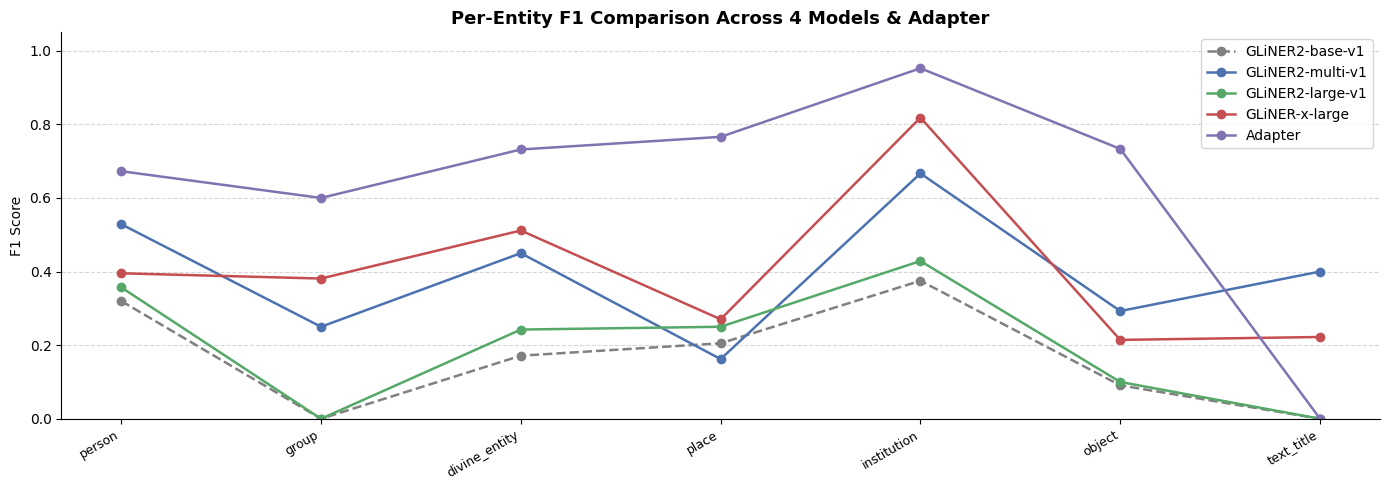

✅ Saved to f1_comparison_models_adapter.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ── Prepare data ─────────────────────────────────────────────────────────────

df_plot = df_f1.loc[df_f1.index != "OVERALL"].copy()

entity_order = [
    "person",
    "group",
    "divine_entity",
    "place",
    "institution",
    "object",
    "text_title"
]

df_plot = df_f1.reindex(entity_order)

labels = df_plot.index.tolist()
x = np.arange(len(labels))

f1_m1 = df_plot["GLiNER2-base-v1"].values
f1_m2 = df_plot["GLiNER2-multi-v1"].values
f1_m3 = df_plot["GLiNER2-large-v1"].values
f1_m4 = df_plot["GLiNER-x-large"].values

# ── Plot ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, f1_m1, color="gray", marker="o",
        linewidth=1.8, markersize=6, linestyle="--", label="GLiNER2-base-v1")

ax.plot(x, f1_m2, color="#4C72B0", marker="o",
        linewidth=1.8, markersize=6, linestyle="-", label="GLiNER2-multi-v1")

ax.plot(x, f1_m3, color="#55A868", marker="o",
        linewidth=1.8, markersize=6, linestyle="-", label="GLiNER2-large-v1")

ax.plot(x, f1_m4, color="#C44E52", marker="o",
        linewidth=1.8, markersize=6, linestyle="-", label="GLiNER-x-large")
ax.plot(x, df_plot["Adapter"].values, color="#8172B2", marker="o",
        linewidth=1.8, markersize=6, linestyle="-", label="Adapter")

# ── Formatting ───────────────────────────────────────────────────────────────

ax.set_title("Per-Entity F1 Comparison Across 4 Models & Adapter",
             fontsize=13, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_yticks(np.arange(0, 1.1, 0.2))

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.legend(fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("f1_comparison_models_adapter.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved to f1_comparison_models_adapter.png")